In [1]:
import librosa
import numpy as np
import matplotlib.pyplot as plt

audio_path = "/content/M4A to WAV REC1.wav"
signal, sr = librosa.load(audio_path, sr=16000, mono=True)


In [2]:
print("Sampling rate:", sr)
print("Signal shape:", signal.shape)
print("Duration (seconds):", len(signal)/sr)
print("Min amplitude:", np.min(signal))
print("Max amplitude:", np.max(signal))


Sampling rate: 16000
Signal shape: (102742,)
Duration (seconds): 6.421375
Min amplitude: -0.52232224
Max amplitude: 0.6196244


**OBJECTIVE1**

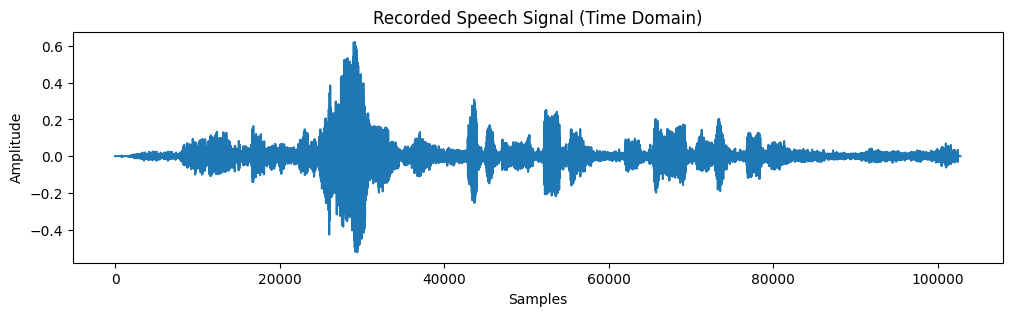

In [3]:
plt.figure(figsize=(12,3))
plt.plot(signal)
plt.title("Recorded Speech Signal (Time Domain)")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.show()


In [4]:
from IPython.display import Audio

Audio(signal, rate=sr)


In [ ]:
#STEP-2

In [8]:
import torch
from transformers import Wav2Vec2Processor, Wav2Vec2ForCTC

processor = Wav2Vec2Processor.from_pretrained(
    "facebook/wav2vec2-base-960h"
)

model = Wav2Vec2ForCTC.from_pretrained(
    "facebook/wav2vec2-base-960h"
)

model.eval()


Loading weights:   0%|          | 0/212 [00:00<?, ?it/s]

Wav2Vec2ForCTC LOAD REPORT from: facebook/wav2vec2-base-960h
Key                        | Status  | 
---------------------------+---------+-
wav2vec2.masked_spec_embed | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Wav2Vec2ForCTC(
  (wav2vec2): Wav2Vec2Model(
    (feature_extractor): Wav2Vec2FeatureEncoder(
      (conv_layers): ModuleList(
        (0): Wav2Vec2GroupNormConvLayer(
          (conv): Conv1d(1, 512, kernel_size=(10,), stride=(5,), bias=False)
          (activation): GELUActivation()
          (layer_norm): GroupNorm(512, 512, eps=1e-05, affine=True)
        )
        (1-4): 4 x Wav2Vec2NoLayerNormConvLayer(
          (conv): Conv1d(512, 512, kernel_size=(3,), stride=(2,), bias=False)
          (activation): GELUActivation()
        )
        (5-6): 2 x Wav2Vec2NoLayerNormConvLayer(
          (conv): Conv1d(512, 512, kernel_size=(2,), stride=(2,), bias=False)
          (activation): GELUActivation()
        )
      )
    )
    (feature_projection): Wav2Vec2FeatureProjection(
      (layer_norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
      (projection): Linear(in_features=512, out_features=768, bias=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder)

In [9]:
inputs = processor(
    signal,
    sampling_rate=sr,
    return_tensors="pt"
)


In [14]:
predicted_ids = torch.argmax(logits, dim=-1)

tokens = processor.tokenizer.convert_ids_to_tokens(
    predicted_ids[0].tolist()
)

print(tokens)



['<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', 'S', 'H', 'H', '<pad>', '<pad>', '<pad>', 'E', '<pad>', '<pad>', '<pad>', '|', '|', '|', '<pad>', '<pad>', '<pad>', '<pad>', 'J', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', 'U', 'D', '<pad>', '<pad>', 'G', 'G', '<pad>', 'E', '<pad>', 'D', '<pad>', '|', '|', '|', '<pad>', 'T', 'H', '<pad>', 'E', '<pad>', '|', '|', 'B', '<pad>', 'L', '<pad>', '<pad>', '<pad>', '<pad>', 'U', '<pad>', 'E', '<pad>', '<pad>', '<pad>', '|', '<pad>', 'M', '<pad>', '<pad>', '<pad>', 'E', '<pad>', 'N', 'N', '<pad>', '<pad>', '|', '|', '|', '|', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', 'W', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', 

In [15]:
phoneme_sequence = []
prev = None

for token in tokens:
    if token != prev and token not in ["<pad>", "|"]:
        phoneme_sequence.append(token)
    prev = token

print("Number of phoneme-like units:", len(phoneme_sequence))
print("First 20 phonemes:", phoneme_sequence[:20])
print("Last 20 phonemes:", phoneme_sequence[-20:])



Number of phoneme-like units: 57
First 20 phonemes: ['S', 'H', 'E', 'J', 'U', 'D', 'G', 'E', 'D', 'T', 'H', 'E', 'B', 'L', 'U', 'E', 'M', 'E', 'N', 'W']
Last 20 phonemes: ['D', 'Q', 'U', 'I', 'E', 'T', 'L', 'Y', 'W', 'H', 'I', 'S', 'P', 'E', 'R', 'E', 'D', 'Y', 'E', 'S']


In [16]:
total_duration = len(signal) / sr
time_per_phoneme = total_duration / len(phoneme_sequence)

phoneme_segments = []
t = 0.0

for ph in phoneme_sequence:
    phoneme_segments.append((ph, t, t + time_per_phoneme))
    t += time_per_phoneme


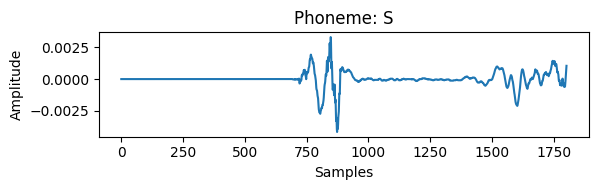

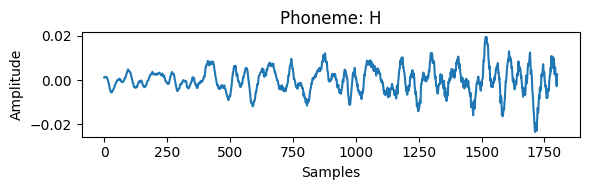

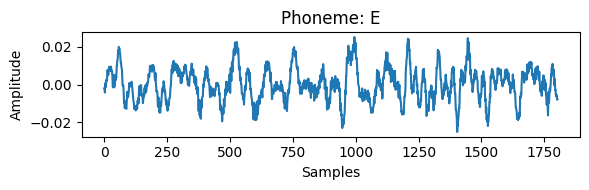

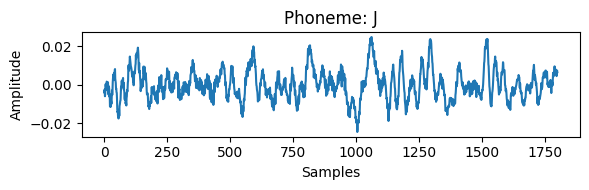

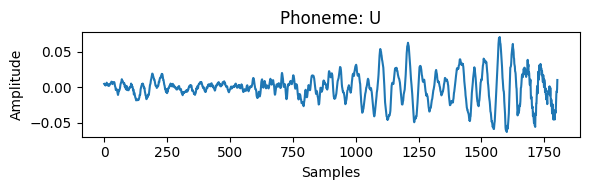

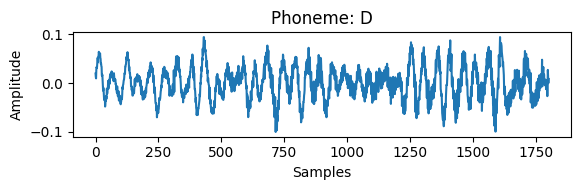

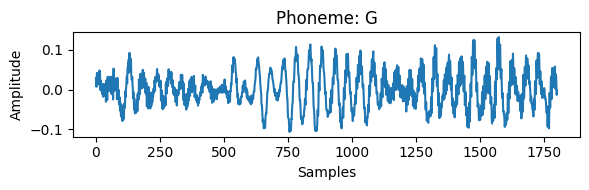

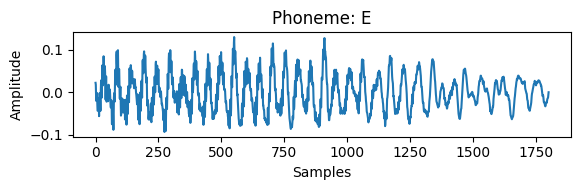

In [17]:
import matplotlib.pyplot as plt

for ph, start, end in phoneme_segments[:8]:  # first few is enough
    s = int(start * sr)
    e = int(end * sr)
    segment = signal[s:e]

    plt.figure(figsize=(6,2))
    plt.plot(segment)
    plt.title(f"Phoneme: {ph}")
    plt.xlabel("Samples")
    plt.ylabel("Amplitude")
    plt.tight_layout()
    plt.show()


In [18]:
phoneme_category = {
    # vowels
    'A':'vowel','E':'vowel','I':'vowel','O':'vowel','U':'vowel',

    # plosives
    'P':'plosive','B':'plosive','T':'plosive','D':'plosive',
    'K':'plosive','G':'plosive',

    # fricatives
    'S':'fricative','F':'fricative','Z':'fricative','H':'fricative',

    # affricates (approximated)
    'J':'affricate','C':'affricate',

    # semivowels / approximants
    'L':'semivowel','R':'semivowel','W':'semivowel','Y':'semivowel',

    # whisper / breathy
    'H':'whisper'
}


In [19]:
for ph, _, _ in phoneme_segments[:15]:
    category = phoneme_category.get(ph, 'unknown')
    print(f"{ph}  →  {category}")


S  →  fricative
H  →  whisper
E  →  vowel
J  →  affricate
U  →  vowel
D  →  plosive
G  →  plosive
E  →  vowel
D  →  plosive
T  →  plosive
H  →  whisper
E  →  vowel
B  →  plosive
L  →  semivowel
U  →  vowel


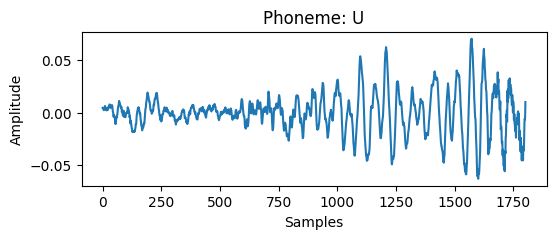

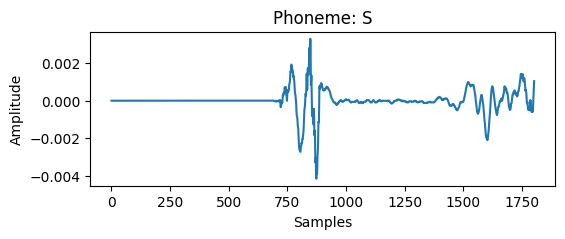

In [20]:
def plot_phoneme(target):
    for ph, start, end in phoneme_segments:
        if ph == target:
            s = int(start * sr)
            e = int(end * sr)
            segment = signal[s:e]

            plt.figure(figsize=(6,2))
            plt.plot(segment)
            plt.title(f"Phoneme: {ph}")
            plt.xlabel("Samples")
            plt.ylabel("Amplitude")
            plt.show()
            break

plot_phoneme('U')   # voiced
plot_phoneme('S')   # unvoiced


“The voiced phoneme (/U/) exhibits quasi-periodic oscillations with higher amplitude, reflecting vocal fold vibration. In contrast, the unvoiced phoneme (/S/) lacks periodicity and shows noise-like fluctuations with lower amplitude due to turbulent airflow at the articulatory constriction.”

# **OBJECTIVE2**

In [21]:
import librosa
import numpy as np
import matplotlib.pyplot as plt

audio_path = "/content/M4A to WAV REC2.wav"

signal2, sr2 = librosa.load(audio_path, sr=16000, mono=True)

print("Sampling rate:", sr2)
print("Signal shape:", signal2.shape)
print("Duration (seconds):", len(signal2)/sr2)
print("Min amplitude:", np.min(signal2))
print("Max amplitude:", np.max(signal2))


Sampling rate: 16000
Signal shape: (50176,)
Duration (seconds): 3.136
Min amplitude: -0.16102946
Max amplitude: 0.16353655


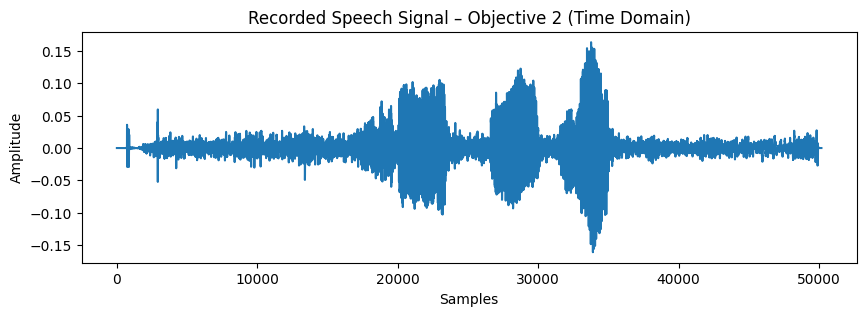

In [22]:
plt.figure(figsize=(10,3))
plt.plot(signal2)
plt.title("Recorded Speech Signal – Objective 2 (Time Domain)")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.show()


In [24]:
import torch
from transformers import Wav2Vec2Processor, Wav2Vec2ForCTC

processor = Wav2Vec2Processor.from_pretrained("facebook/wav2vec2-base-960h")
model = Wav2Vec2ForCTC.from_pretrained("facebook/wav2vec2-base-960h")
model.eval()

inputs = processor(signal2, sampling_rate=sr2, return_tensors="pt")

with torch.no_grad():
    logits = model(inputs.input_values).logits

predicted_ids = torch.argmax(logits, dim=-1)

tokens2 = processor.tokenizer.convert_ids_to_tokens(
    predicted_ids[0].tolist()
)

print(tokens2)


Loading weights:   0%|          | 0/212 [00:00<?, ?it/s]

Wav2Vec2ForCTC LOAD REPORT from: facebook/wav2vec2-base-960h
Key                        | Status  | 
---------------------------+---------+-
wav2vec2.masked_spec_embed | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


['<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', 'S', '<pad>', 'H', 'H', '<pad>', '<pad>', '<pad>', 'E', 'E', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '|', '|', '<pad>', '<pad>', '<pad>', '<pad>', 'S', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', 'E', '<pad>', '<pad>', '<pad>', '<pad>', 'E', '<pad>', '<pad>', '<pad>', '<pad>', 'S', '<pad>', '<pad>', '|', '<pad>', '<pad>', 'Y', '<pad>', '<pad>', '<pad>', 'O', 'U', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '|', '|', '|', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', 

In [25]:
phoneme_sequence2 = []
prev = None

for tok in tokens2:
    if tok != prev and tok not in ["<pad>", "|"]:
        phoneme_sequence2.append(tok)
    prev = tok

print("Phoneme-like units:", phoneme_sequence2)
print("Total units:", len(phoneme_sequence2))


Phoneme-like units: ['S', 'H', 'E', 'S', 'E', 'E', 'S', 'Y', 'O', 'U']
Total units: 10


In [28]:
#Frigatives and approximant
# Estimate phoneme time intervals (same approximation as Lab-2)
total_duration2 = len(signal2) / sr2
time_per_ph2 = total_duration2 / len(phoneme_sequence2)

phoneme_segments2 = []
t = 0.0

for ph in phoneme_sequence2:
    phoneme_segments2.append((ph, t, t + time_per_ph2))
    t += time_per_ph2

# Isolate fricatives and approximant
target_phonemes = ['S', 'H', 'Y']

selected_segments = [
    (ph, start, end)
    for ph, start, end in phoneme_segments2
    if ph in target_phonemes
]

print("Selected segments:", selected_segments)


Selected segments: [('S', 0.0, 0.3136), ('H', 0.3136, 0.6272), ('S', 0.9408, 1.2544), ('S', 1.8816000000000002, 2.1952000000000003), ('Y', 2.1952000000000003, 2.5088000000000004)]


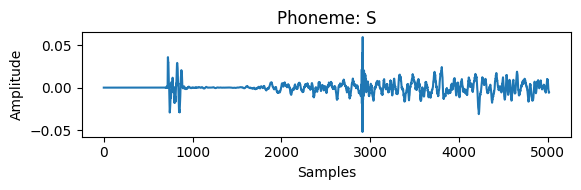

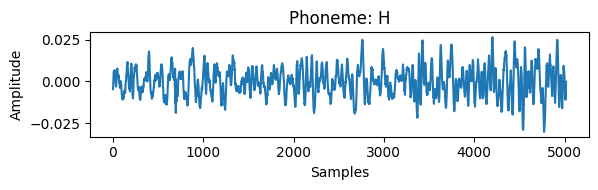

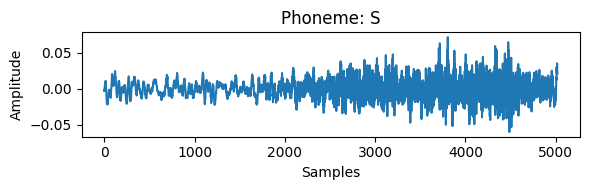

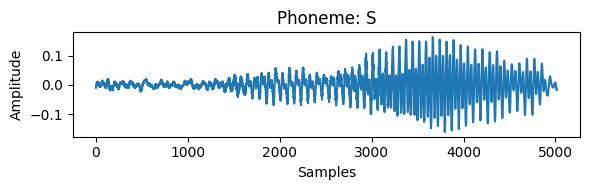

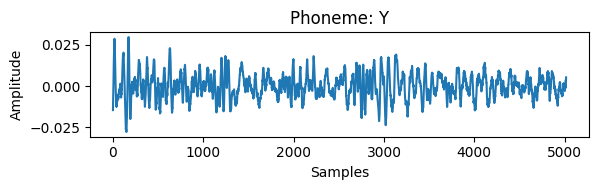

In [29]:
import matplotlib.pyplot as plt

for ph, start, end in selected_segments:
    s = int(start * sr2)
    e = int(end * sr2)
    segment = signal2[s:e]

    plt.figure(figsize=(6,2))
    plt.plot(segment)
    plt.title(f"Phoneme: {ph}")
    plt.xlabel("Samples")
    plt.ylabel("Amplitude")
    plt.tight_layout()
    plt.show()


Step vi (Observations)

“The fricative /s/ exhibits an irregular, aperiodic waveform with prominent noise-like fluctuations and varying amplitude. The approximant /j/ shows a smoother waveform with weak periodicity and continuous amplitude, indicating reduced turbulence.”

Step vii (Airflow & Reynolds number)

“Fricatives are produced with turbulent airflow due to narrow articulatory constriction, corresponding to a higher effective Reynolds number. Approximants are produced with smoother, laminar airflow associated with a lower effective Reynolds number.”

Step viii (Comparison)

“Fricatives display higher waveform irregularity, lack of periodicity, and greater energy variation compared to approximants. These differences arise from tighter articulatory constrictions in fricatives versus wider constrictions in approximants.”